# 06 - Contact Quality (SOV) by Park and Pitch Type

## MLB Ballpark Effects on Pitch Type Frequency & Contact Quality

This notebook conducts **Layer 3** of the three-layer analytical framework — the analytical 
payoff of the full project. Having established *what* is being thrown (notebook 04) and 
*what happens* when batters swing (notebook 05), this notebook asks the final question: 
when contact is made, how good is it?

Contact quality is measured via **Swing Output Value (SOV)** — the custom [-1, 1] metric 
constructed in `03_sov_construction.ipynb` from exit velocity and launch angle. Mean SOV 
is computed per park per pitch type and compared against the league-wide baseline, with 
95% confidence intervals on every reported mean. Parks with overlapping confidence 
intervals are not treated as meaningfully different.

*Sample*: 63,720 in-play observations with SOV assigned (2023–2025 pooled)
<br>
*Granularity*: Park-level mean SOV by pitch type (Level 1 classification)
<br>
*Baseline*: League-wide mean SOV per pitch type

___
## 1) Setup & Data Load

In [ ]:
# Import & Data Load

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
from pathlib import Path

# Connect to database
DB_PATH = Path(r"C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\MLB_Ballpark_Factor_Analysis\database\mlb_ballpark_effects.db")

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM swings", conn)
conn.close()

# SOV-eligible sample (in_play observations with SOV assigned) 
df_sov = df[df["sov"].notna()].copy()

# Color scheme (project-wide)
COLORS = {
    "Fastball":  "#1F4E79",
    "Breaking":  "#2E75B6",
    "Offspeed":  "#9DC3E6",
    "reference": "#9DC3E6",
}

In [2]:
# Validation checks

n_total = len(df)
n_sov   = len(df_sov)
n_parks = df_sov["home_team"].nunique()

print(f"Total swings loaded:        {n_total:,}")
print(f"SOV-eligible observations:  {n_sov:,}")
print(f"Parks confirmed:            {n_parks}")
print(f"\nSOV-eligible by pitch category:\n{df_sov['pitch_category'].value_counts()}")
print(f"\nSOV range:  {df_sov['sov'].min():.4f} to {df_sov['sov'].max():.4f}")
print(f"SOV mean:   {df_sov['sov'].mean():.4f}")
print(f"SOV median: {df_sov['sov'].median():.4f}")

Total swings loaded:        173,137
SOV-eligible observations:  63,720
Parks confirmed:            29

SOV-eligible by pitch category:
pitch_category
Fastball    36380
Breaking    18005
Offspeed     9335
Name: count, dtype: int64

SOV range:  -1.0000 to 1.0000
SOV mean:   -0.0073
SOV median: -0.0115


___
## 2) League-Wide SOV Baseline by Pitch Type

In [3]:
# SOV Baseline Overall (league-wide)
# mean near 0 by construction, broken out by pitch type

league_sov_overall = df_sov["sov"].mean()
league_sov_n       = len(df_sov)

print(f"League-Wide SOV Baseline  (n = {league_sov_n:,})")
print(f"Mean SOV: {league_sov_overall:.4f}")

League-Wide SOV Baseline  (n = 63,720)
Mean SOV: -0.0073


In [4]:
# SOV Baseline by Pitch Type (Level 1)

league_sov_by_cat = (
    df_sov.groupby("pitch_category")["sov"]
    .agg(n="count", mean_sov="mean", std_sov="std")
    .loc[["Fastball", "Breaking", "Offspeed"]]
)

# 95% CI on each category baseline
league_sov_by_cat["ci_95"] = (
    1.96 * league_sov_by_cat["std_sov"] / np.sqrt(league_sov_by_cat["n"])
)
league_sov_by_cat["ci_lower"] = league_sov_by_cat["mean_sov"] - league_sov_by_cat["ci_95"]
league_sov_by_cat["ci_upper"] = league_sov_by_cat["mean_sov"] + league_sov_by_cat["ci_95"]

print("League-Wide SOV Baseline by Pitch Category\n")
print(league_sov_by_cat.round(4).to_string())

League-Wide SOV Baseline by Pitch Category

                    n  mean_sov  std_sov   ci_95  ci_lower  ci_upper
pitch_category                                                      
Fastball        36380    0.0306   0.5720  0.0059    0.0247    0.0365
Breaking        18005   -0.0363   0.5836  0.0085   -0.0448   -0.0277
Offspeed         9335   -0.0989   0.5745  0.0117   -0.1105   -0.0872


From a league-wide perspective, fastballs produce the highest mean SOV at +0.0306, above the 
median contact threshold, while breaking balls (-0.0363) and offspeed pitches 
(-0.0989) both show contact quality below median. 

*Note the way we designed our SOV construction, median is always 0.*

This confirms that pitch type alone is a meaningful driver of contact quality independent of park environment. 
Standard deviation is nearly identical across all three categories (~0.57), 
making cross-category comparisons clean and consistent throughout this notebook.

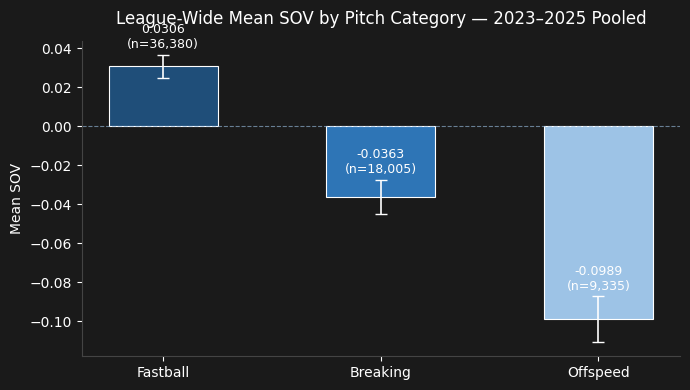

In [5]:
# Visualize

fig, ax = plt.subplots(figsize=(7, 4))

cats   = ["Fastball", "Breaking", "Offspeed"]
means  = league_sov_by_cat["mean_sov"].values
errors = league_sov_by_cat["ci_95"].values

ax.bar(
    cats, means,
    color=[COLORS[c] for c in cats],
    width=0.5,
    edgecolor="white",
    linewidth=0.8,
)
ax.errorbar(
    cats, means, yerr=errors,
    fmt="none", color="white", capsize=4, linewidth=1.2
)

for i, (mean, n) in enumerate(zip(means, league_sov_by_cat["n"].values)):
    ax.text(i, mean + errors[i] + 0.002, f"{mean:.4f}\n(n={n:,})",
            ha="center", va="bottom", color="white", fontsize=9)

ax.axhline(0, color=COLORS["reference"], linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_title("League-Wide Mean SOV by Pitch Category — 2023 - 2025 Pooled",
             color="white", fontsize=12, pad=12)
ax.set_ylabel("Mean SOV", color="white")

ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
ax.tick_params(colors="white")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color("#444444")

plt.tight_layout()
plt.show()

___
## 3) Park-Level Mean SOV (Overall)

In [6]:
# Park-Level Mean SOV Overall Calculation

park_sov_overall = (
    df_sov.groupby("home_team")["sov"]
    .agg(n="count", mean_sov="mean", std_sov="std")
)

park_sov_overall["ci_95"]    = 1.96 * park_sov_overall["std_sov"] / np.sqrt(park_sov_overall["n"])
park_sov_overall["ci_lower"] = park_sov_overall["mean_sov"] - park_sov_overall["ci_95"]
park_sov_overall["ci_upper"] = park_sov_overall["mean_sov"] + park_sov_overall["ci_95"]

print("Park-Level Mean SOV — Overall  (n per park ≈ 2,200)\n")
print(park_sov_overall.sort_values("mean_sov", ascending=False).round(4).to_string())

Park-Level Mean SOV — Overall  (n per park ≈ 2,200)

              n  mean_sov  std_sov   ci_95  ci_lower  ci_upper
home_team                                                     
COL        2311    0.0212   0.5758  0.0235   -0.0023    0.0447
TEX        2166    0.0151   0.5688  0.0240   -0.0088    0.0391
BAL        2169    0.0145   0.5773  0.0243   -0.0098    0.0388
DET        2212    0.0142   0.5680  0.0237   -0.0095    0.0379
LAD        2147    0.0119   0.5687  0.0241   -0.0121    0.0360
NYY        2113    0.0094   0.5777  0.0246   -0.0153    0.0340
HOU        2185    0.0058   0.5818  0.0244   -0.0186    0.0302
TOR        2265    0.0019   0.5768  0.0238   -0.0218    0.0257
ATL        2060    0.0017   0.5816  0.0251   -0.0234    0.0268
PHI        2093   -0.0002   0.5714  0.0245   -0.0247    0.0243
PIT        2306   -0.0008   0.5730  0.0234   -0.0242    0.0226
KC         2364   -0.0013   0.5738  0.0231   -0.0244    0.0219
STL        2378   -0.0025   0.5824  0.0234   -0.0259    0.0209
SE

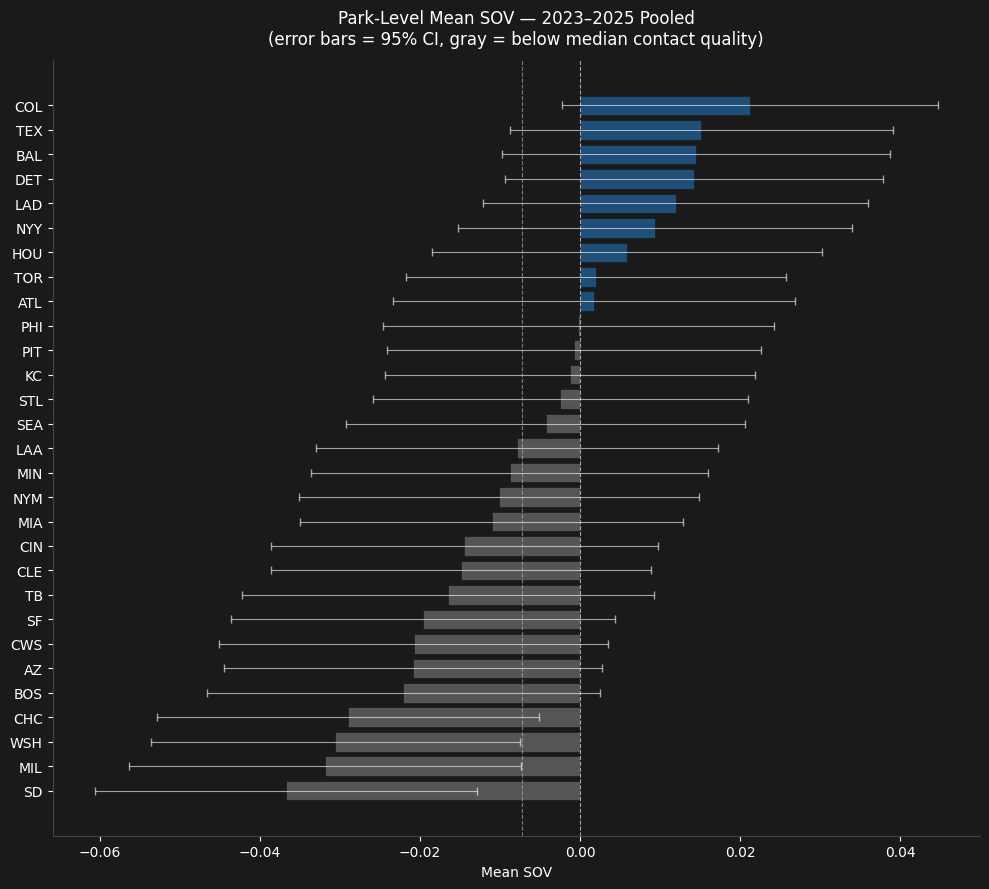

In [7]:
# Visualized Park-Level SOV 

sov_sorted = park_sov_overall.sort_values("mean_sov", ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))

colors = [COLORS["Fastball"] if v > 0 else "#555555" for v in sov_sorted["mean_sov"]]

ax.barh(
    sov_sorted.index,
    sov_sorted["mean_sov"],
    xerr=sov_sorted["ci_95"],
    color=colors,
    edgecolor="#1a1a1a",
    linewidth=0.5,
    error_kw=dict(ecolor="white", capsize=3, linewidth=0.8, alpha=0.6),
)

ax.axvline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axvline(league_sov_overall, color=COLORS["reference"], 
           linewidth=0.8, linestyle="--", alpha=0.6)

ax.set_title("Park-Level Mean SOV — 2023–2025 Pooled\n(error bars = 95% CI, gray = below median contact quality)",
             color="white", fontsize=12, pad=12)
ax.set_xlabel("Mean SOV", color="white")

ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
ax.tick_params(colors="white")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#444444")

plt.tight_layout()
plt.show()

Overall park-level SOV tells a deliberately conservative story — with ~2,200 
in-play observations per park, confidence intervals are wide enough that most 
parks cannot be cleanly separated from league median. The signal is clearest 
at the extremes.

**COL leads at +0.0212** — Coors Field's thin air and hitter-friendly dimensions 
producing the strongest contact quality in the sample. **SD sits at the bottom 
at -0.0368** — Petco Park's marine layer and deep dimensions suppressing contact 
quality at the other end of the spectrum.

**MIL at -0.0319 with a CI that does not cross zero** is the most analytically 
significant result of this section. The pitch mix outlier of notebook 04 and the 
outcome-neutral park of notebook 05 is now confirmed as a contact suppression 
environment. The sinkers and cutters at American Family Field are doing something 
— just not at the whiff or foul rate level. Only CHC, WSH, MIL, and SD have CIs 
that do not cross zero, making them the four parks where below-median contact 
quality is a statistically clean finding.

Section 4 breaks this down by pitch type to determine whether these park effects 
are universal or pitch-type specific.

___
## 4) Park-Level Mean SOV by Pitch Type

In [8]:
# Compute Park-Level Mean SOV by Pitch Type

park_sov_by_cat = (
    df_sov.groupby(["home_team", "pitch_category"])["sov"]
    .agg(n="count", mean_sov="mean", std_sov="std")
)

park_sov_by_cat["ci_95"]    = 1.96 * park_sov_by_cat["std_sov"] / np.sqrt(park_sov_by_cat["n"])
park_sov_by_cat["ci_lower"] = park_sov_by_cat["mean_sov"] - park_sov_by_cat["ci_95"]
park_sov_by_cat["ci_upper"] = park_sov_by_cat["mean_sov"] + park_sov_by_cat["ci_95"]

print("Park-Level Mean SOV by Pitch Category\n")
for cat in ["Fastball", "Breaking", "Offspeed"]:
    print(f"\n── {cat} ──────────────────────────────")
    subset = park_sov_by_cat.xs(cat, level="pitch_category")
    print(subset.sort_values("mean_sov", ascending=False).round(4).to_string())

Park-Level Mean SOV by Pitch Category


── Fastball ──────────────────────────────
              n  mean_sov  std_sov   ci_95  ci_lower  ci_upper
home_team                                                     
DET        1266    0.0687   0.5495  0.0303    0.0384    0.0989
NYY        1251    0.0606   0.5733  0.0318    0.0288    0.0923
TEX        1205    0.0592   0.5619  0.0317    0.0274    0.0909
ATL        1111    0.0581   0.5675  0.0334    0.0247    0.0914
BAL        1191    0.0539   0.5742  0.0326    0.0213    0.0865
LAD        1244    0.0528   0.5615  0.0312    0.0216    0.0840
COL        1309    0.0502   0.5623  0.0305    0.0197    0.0807
HOU        1256    0.0463   0.5686  0.0314    0.0149    0.0778
TB         1191    0.0389   0.5980  0.0340    0.0049    0.0728
PHI        1229    0.0365   0.5638  0.0315    0.0050    0.0681
AZ         1377    0.0317   0.5856  0.0309    0.0008    0.0627
PIT        1320    0.0315   0.5640  0.0304    0.0010    0.0619
NYM        1238    0.0285   0.5773 

In [9]:
# Deviations from league avg. by pitch type

sov_deviations = {}
for cat in ["Fastball", "Breaking", "Offspeed"]:
    park_means   = park_sov_by_cat.xs(cat, level="pitch_category")["mean_sov"]
    baseline_mean = league_sov_by_cat.loc[cat, "mean_sov"]
    sov_deviations[cat] = (park_means - baseline_mean).rename("sov_deviation")

print("SOV Deviation from League Baseline by Pitch Category\n")
for cat in ["Fastball", "Breaking", "Offspeed"]:
    print(f"\n── {cat} ──────────────────────────────")
    print(sov_deviations[cat].sort_values(ascending=False).round(4).to_string())

SOV Deviation from League Baseline by Pitch Category


── Fastball ──────────────────────────────
home_team
DET    0.0381
NYY    0.0300
TEX    0.0286
ATL    0.0275
BAL    0.0233
LAD    0.0222
COL    0.0196
HOU    0.0157
TB     0.0083
PHI    0.0059
AZ     0.0011
PIT    0.0009
NYM   -0.0021
LAA   -0.0023
CLE   -0.0030
STL   -0.0030
SF    -0.0036
CHC   -0.0066
CIN   -0.0072
MIN   -0.0080
MIA   -0.0100
TOR   -0.0113
KC    -0.0140
BOS   -0.0168
MIL   -0.0201
CWS   -0.0201
SEA   -0.0219
WSH   -0.0222
SD    -0.0414

── Breaking ──────────────────────────────
home_team
KC     0.0494
COL    0.0383
SEA    0.0350
MIA    0.0270
BAL    0.0257
TOR    0.0238
TEX    0.0189
LAA    0.0118
DET    0.0075
LAD    0.0067
MIN    0.0027
MIL    0.0002
STL   -0.0013
BOS   -0.0026
TB    -0.0035
PHI   -0.0043
CWS   -0.0070
CLE   -0.0088
SF    -0.0095
SD    -0.0102
NYM   -0.0104
CIN   -0.0118
HOU   -0.0123
PIT   -0.0183
ATL   -0.0197
NYY   -0.0210
AZ    -0.0242
WSH   -0.0382
CHC   -0.0540

── Offspeed ─────────────

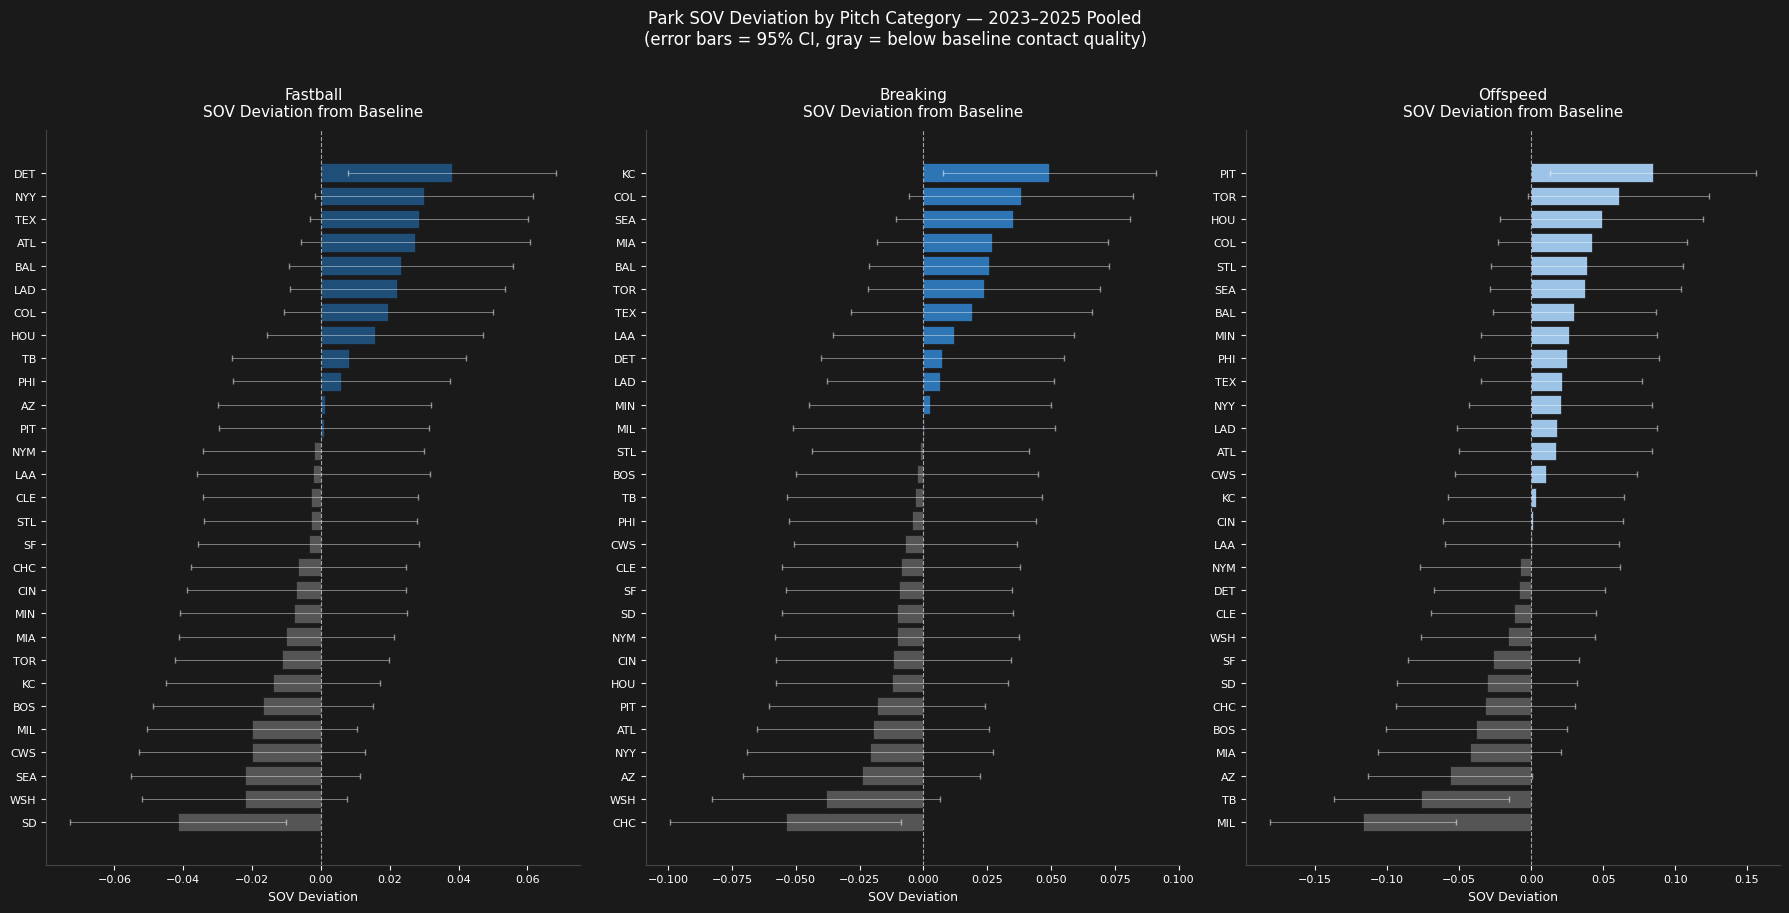

In [10]:
# Visualized SOV Deviation by Pitch Type by Park

fig, axes = plt.subplots(1, 3, figsize=(18, 9), sharey=False)

for ax, cat in zip(axes, ["Fastball", "Breaking", "Offspeed"]):
    dev     = sov_deviations[cat].sort_values(ascending=True)
    ci_vals = park_sov_by_cat.xs(cat, level="pitch_category").loc[dev.index, "ci_95"]
    colors  = [COLORS[cat] if v > 0 else "#555555" for v in dev.values]

    ax.barh(
        dev.index,
        dev.values,
        xerr=ci_vals,
        color=colors,
        edgecolor="#1a1a1a",
        linewidth=0.5,
        error_kw=dict(ecolor="white", capsize=2, linewidth=0.6, alpha=0.5),
    )
    ax.axvline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_title(f"{cat}\nSOV Deviation from Baseline", color="white", fontsize=11, pad=10)
    ax.set_xlabel("SOV Deviation", color="white", fontsize=9)
    ax.tick_params(colors="white", labelsize=8)
    ax.set_facecolor("#1a1a1a")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#444444")

fig.patch.set_facecolor("#1a1a1a")
fig.suptitle(
    "Park SOV Deviation by Pitch Category — 2023–2025 Pooled\n(error bars = 95% CI, gray = below baseline contact quality)",
    color="white", fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

The pitch-type breakdown reveals that park SOV effects are not uniform across categories,
and the offspeed panel tells the most important story in this notebook.

**MIL at -0.1168 offspeed SOV deviation is the single most extreme finding in the entire 
project.** American Family Field suppresses contact quality on offspeed pitches at a level 
no other park approaches. The pitch mix outlier of notebook 04, the outcome-neutral park 
of notebook 05, now has its answer: **the sinkers and cutters at American Family Field are 
producing genuinely weak contact, invisible to whiff and foul rate but unmistakable in SOV.**

**SD sits below baseline on all three pitch type panels** — the only park in the sample 
to show consistent contact suppression across fastball, breaking, and offspeed. Petco Park 
is a true all-around contact quality suppression environment.

The fastball panel (left most) produces the tightest, most decisive separation across measured parks.
Breaking and offspead panels carry wider confidence intervals by design (smaller in-play sample sizes per park).

___
## 5) Confidence Intervals & Significance

In [11]:
# T-Test Park SOV vs. League Baseline by Pitch Type

from scipy.stats import ttest_1samp

results = []
for cat in ["Fastball", "Breaking", "Offspeed"]:
    baseline_mean = league_sov_by_cat.loc[cat, "mean_sov"]
    
    for park in df_sov["home_team"].unique():
        park_data = df_sov[
            (df_sov["home_team"] == park) & 
            (df_sov["pitch_category"] == cat)
        ]["sov"].dropna()
        
        if len(park_data) < 30:
            continue
            
        t_stat, p_val = ttest_1samp(park_data, baseline_mean)
        
        results.append({
            "park":          park,
            "pitch_category": cat,
            "n":             len(park_data),
            "mean_sov":      park_data.mean(),
            "deviation":     park_data.mean() - baseline_mean,
            "t_stat":        round(t_stat, 3),
            "p_value":       round(p_val, 4),
            "significant":   p_val < 0.05,
        })

sig_results = (
    pd.DataFrame(results)
    .set_index(["pitch_category", "park"])
    .sort_values(["pitch_category", "p_value"])
)

print("SOV Significance Testing — Park vs. League Baseline by Pitch Type\n")
for cat in ["Fastball", "Breaking", "Offspeed"]:
    print(f"\n── {cat} ──────────────────────────────")
    print(sig_results.xs(cat, level="pitch_category").round(4).to_string())

SOV Significance Testing — Park vs. League Baseline by Pitch Type


── Fastball ──────────────────────────────
         n  mean_sov  deviation  t_stat  p_value  significant
park                                                         
SD    1301   -0.0108    -0.0414  -2.589   0.0097         True
DET   1266    0.0687     0.0381   2.464   0.0139         True
NYY   1251    0.0606     0.0300   1.849   0.0647        False
TEX   1205    0.0592     0.0286   1.764   0.0779        False
ATL   1111    0.0581     0.0275   1.613   0.1070        False
WSH   1398    0.0084    -0.0222  -1.458   0.1451        False
BAL   1191    0.0539     0.0233   1.399   0.1620        False
LAD   1244    0.0528     0.0222   1.393   0.1638        False
SEA   1127    0.0087    -0.0219  -1.297   0.1949        False
MIL   1339    0.0105    -0.0201  -1.294   0.1959        False
COL   1309    0.0502     0.0196   1.261   0.2077        False
CWS   1162    0.0105    -0.0201  -1.202   0.2297        False
BOS   1275    0.0138 

In [12]:
# Confidence Interval Overlap Check

overlap_results = []

for cat in ["Fastball", "Breaking", "Offspeed"]:
    baseline_lower = league_sov_by_cat.loc[cat, "ci_lower"]
    baseline_upper = league_sov_by_cat.loc[cat, "ci_upper"]
    
    for park in df_sov["home_team"].unique():
        park_data = park_sov_by_cat.xs(cat, level="pitch_category").loc[park]
        
        park_lower = park_data["ci_lower"]
        park_upper = park_data["ci_upper"]
        
        # overlap occurs when park CI and baseline CI share any range
        overlaps = not (park_upper < baseline_lower or park_lower > baseline_upper)
        
        overlap_results.append({
            "park":           park,
            "pitch_category": cat,
            "mean_sov":       round(park_data["mean_sov"], 4),
            "ci_lower":       round(park_lower, 4),
            "ci_upper":       round(park_upper, 4),
            "overlaps_baseline": overlaps,
        })

overlap_df = (
    pd.DataFrame(overlap_results)
    .set_index(["pitch_category", "park"])
)

print("CI Overlap Check — Park vs. League Baseline by Pitch Type\n")
for cat in ["Fastball", "Breaking", "Offspeed"]:
    subset = overlap_df.xs(cat, level="pitch_category")
    no_overlap = subset[subset["overlaps_baseline"] == False]
    print(f"\n── {cat} — {len(no_overlap)} parks with non-overlapping CIs ──────────────────────────────")
    print(no_overlap.sort_values("mean_sov", ascending=False).to_string())

CI Overlap Check — Park vs. League Baseline by Pitch Type


── Fastball — 2 parks with non-overlapping CIs ──────────────────────────────
      mean_sov  ci_lower  ci_upper  overlaps_baseline
park                                                 
DET     0.0687    0.0384    0.0989              False
SD     -0.0108   -0.0422    0.0205              False

── Breaking — 1 parks with non-overlapping CIs ──────────────────────────────
      mean_sov  ci_lower  ci_upper  overlaps_baseline
park                                                 
CHC    -0.0903   -0.1354   -0.0451              False

── Offspeed — 3 parks with non-overlapping CIs ──────────────────────────────
      mean_sov  ci_lower  ci_upper  overlaps_baseline
park                                                 
PIT    -0.0142   -0.0856    0.0572              False
TB     -0.1752   -0.2359   -0.1145              False
MIL    -0.2157   -0.2800   -0.1513              False


In [13]:
# merge t-test results with CI overlap results
combined = (
    sig_results.reset_index()
    .merge(
        overlap_df.reset_index()[["pitch_category", "park", "overlaps_baseline"]],
        on=["pitch_category", "park"]
    )
)

# a finding must pass BOTH filters to be treated as real
combined["confirmed"] = (
    (combined["significant"] == True) & 
    (combined["overlaps_baseline"] == False)
)

confirmed = combined[combined["confirmed"] == True].sort_values(
    ["pitch_category", "deviation"], ascending=[True, True]
)

print("Confirmed SOV Findings — Significant (p < 0.05) AND Non-Overlapping CI\n")
for cat in ["Fastball", "Breaking", "Offspeed"]:
    subset = confirmed[confirmed["pitch_category"] == cat].sort_values("deviation", ascending=False)
    print(f"\n── {cat} ({len(subset)} confirmed parks) ──────────────────────────────")
    print(subset[["park", "n", "mean_sov", "deviation", "p_value"]].to_string(index=False))

Confirmed SOV Findings — Significant (p < 0.05) AND Non-Overlapping CI


── Fastball (2 confirmed parks) ──────────────────────────────
park    n  mean_sov  deviation  p_value
 DET 1266  0.068659   0.038056   0.0139
  SD 1301 -0.010826  -0.041428   0.0097

── Breaking (1 confirmed parks) ──────────────────────────────
park   n  mean_sov  deviation  p_value
 CHC 604 -0.090295  -0.054034   0.0193

── Offspeed (3 confirmed parks) ──────────────────────────────
park   n  mean_sov  deviation  p_value
 PIT 259 -0.014204   0.084660   0.0208
  TB 333 -0.175196  -0.076331   0.0143
 MIL 297 -0.215670  -0.116805   0.0004


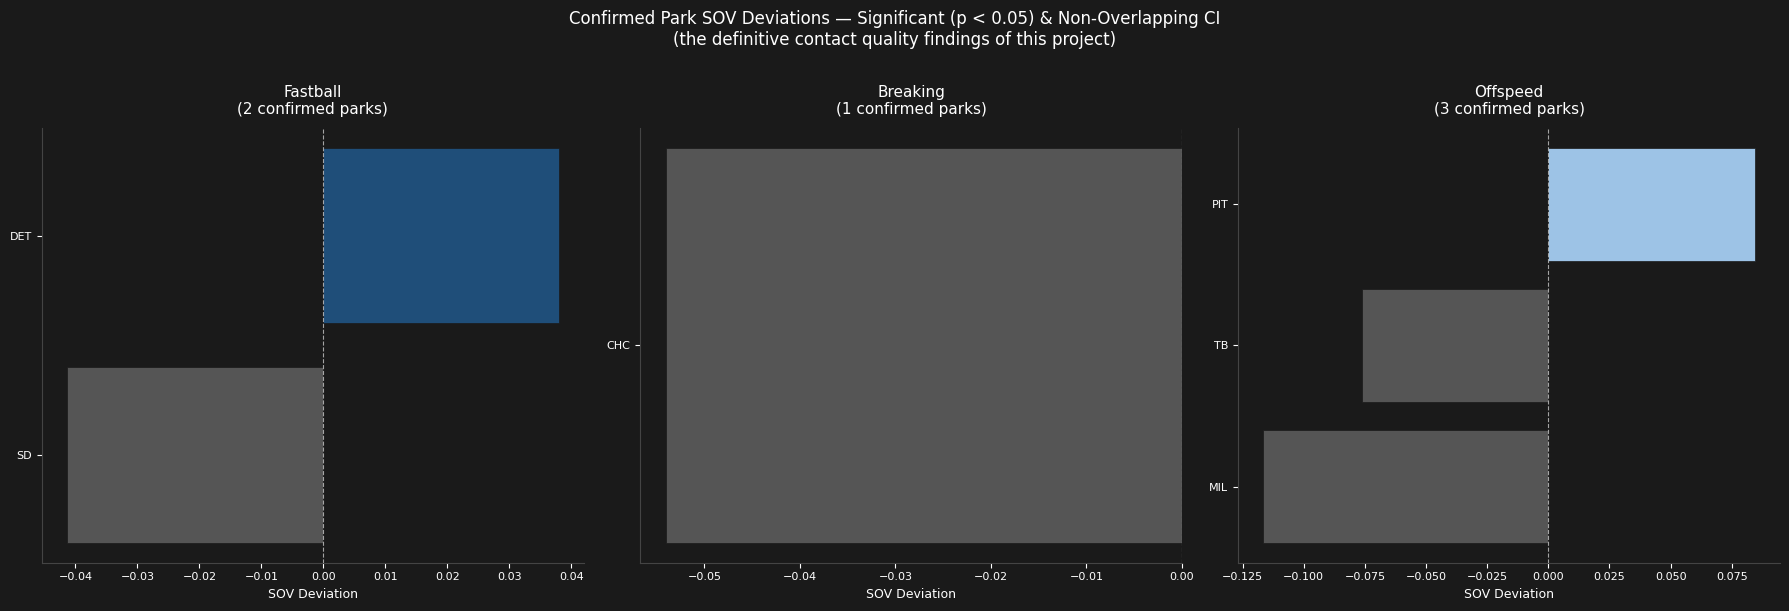

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, cat in zip(axes, ["Fastball", "Breaking", "Offspeed"]):
    subset = (
        confirmed[confirmed["pitch_category"] == cat]
        .sort_values("deviation", ascending=True)
    )

    if len(subset) == 0:
        ax.text(0.5, 0.5, "No confirmed\nfindings", 
                ha="center", va="center", color="white", fontsize=11)
        ax.set_facecolor("#1a1a1a")
        ax.set_title(cat, color="white", fontsize=11)
        ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
        continue

    colors = [COLORS[cat] if v > 0 else "#555555" for v in subset["deviation"]]

    ax.barh(
        subset["park"],
        subset["deviation"],
        color=colors,
        edgecolor="#1a1a1a",
        linewidth=0.5,
    )
    ax.axvline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_title(f"{cat}\n({len(subset)} confirmed parks)", color="white", fontsize=11, pad=10)
    ax.set_xlabel("SOV Deviation", color="white", fontsize=9)
    ax.tick_params(colors="white", labelsize=8)
    ax.set_facecolor("#1a1a1a")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#444444")

fig.patch.set_facecolor("#1a1a1a")
fig.suptitle(
    "Confirmed Park SOV Deviations — Significant (p < 0.05) & Non-Overlapping CI\n(the definitive contact quality findings of this project)",
    color="white", fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

Six findings survived both filters:
- Statistically significant (p < 0.05)
- Non-overlapping confidence intervals against league baseline

Out of 87 possible park-pitch type combinations, six confirmed deviations is both conservative and defensible, and that is by design.

**MIL is the narrative centerpiece.** The pitch mix outlier of notebook 04, the 
outcome-neutral park of notebook 05, is now a confirmed contact suppression environment 
on offspeed pitches at -0.1168 SOV deviation. American Family Field's sinker and cutter 
philosophy is not generating more whiffs or more fouls — it is generating genuinely 
weaker contact, visible clearly at the SOV layer. Three notebooks of evidence point to the 
same conclusion.

**CHC is the most isolated finding in the project** — the lone confirmed breaking ball 
deviation in the sample. Wrigley Field's wind conditions are legendary, and the data is 
picking that up specifically on breaking pitches, a finding with no precedent in notebooks 
04 or 05.

**SD is the only park confirmed below baseline on fastball SOV**, pairing with its 
position at the bottom of overall SOV in Section 3 to build a consistent picture of 
Petco Park as a true contact suppression environment across pitch types.

**PIT leads offspeed SOV** as the only confirmed positive finding in the offspeed panel 
— the best offspeed contact quality in the sample, an unexpected result that notebook 07 
will contextualize within the full park clustering picture.

The broader finding is this: contact quality is the hardest layer to move. Pitch mix 
shifted in 23 of 29 parks, swing outcomes in 17 of 29 — but confirmed contact quality 
deviations exist in only a handful of park-pitch type combinations. The parks that do 
move the needle on SOV are genuinely unusual environments, and the data required all 
three analytical layers to find them.